In [39]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from  xgboost import XGBClassifier 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score,recall_score,f1_score 
import shap

C:\Users\Shubham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
%pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Shubham\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [41]:
data = pd.read_csv(
    'Fraud.csv',
    dtype={
        'type': 'category'
    },
    usecols=['step','type','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']
)

In [42]:
for col in ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']:
    data[col] = data[col].astype('float32')

In [43]:
data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int64   
 1   type            category
 2   amount          float32 
 3   oldbalanceOrg   float32 
 4   newbalanceOrig  float32 
 5   oldbalanceDest  float32 
 6   newbalanceDest  float32 
 7   isFraud         int64   
dtypes: category(1), float32(5), int64(2)
memory usage: 224.5 MB


In [44]:
data.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [45]:
data.head(5)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.639648,170136.0,160296.359375,0.0,0.0,0
1,1,PAYMENT,1864.280029,21249.0,19384.720703,0.0,0.0,0
2,1,TRANSFER,181.000000,181.0,0.000000,0.0,0.0,1
3,1,CASH_OUT,181.000000,181.0,0.000000,21182.0,0.0,1
4,1,PAYMENT,11668.139648,41554.0,29885.859375,0.0,0.0,0


In [46]:
data['balance_error'] = (data['oldbalanceOrg'] - data['newbalanceOrig'] + data['amount'])
+ (data['newbalanceDest'] - data['oldbalanceDest'] - data['amount'])


0         -9.839640e+03
1         -1.864280e+03
2         -1.810000e+02
3         -2.136300e+04
4         -1.166814e+04
               ...     
6362615    0.000000e+00
6362616   -6.311410e+06
6362617   -5.000000e-01
6362618   -8.500025e+05
6362619    0.000000e+00
Length: 6362620, dtype: float32

In [47]:
data['balance_error'].sum()

np.float32(1.00931096e+12)

In [48]:
data['is_balance_mismatch'] = ((data['oldbalanceOrg'] - data['newbalanceOrig'] != data['amount'])).astype(int)

In [49]:
print("I identified inconsistencies in transaction balance flows where transferred amounts were not reflected in destination accounts,\n which strongly correlated with fraudulent behavior")

I identified inconsistencies in transaction balance flows where transferred amounts were not reflected in destination accounts,
 which strongly correlated with fraudulent behavior


In [50]:
data[data['isFraud'] == 1]

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_error,is_balance_mismatch
2,1,TRANSFER,181.000,181.000,0.0,0.000000e+00,0.000,1,362.00,0
3,1,CASH_OUT,181.000,181.000,0.0,2.118200e+04,0.000,1,362.00,0
251,1,TRANSFER,2806.000,2806.000,0.0,0.000000e+00,0.000,1,5612.00,0
252,1,CASH_OUT,2806.000,2806.000,0.0,2.620200e+04,0.000,1,5612.00,0
680,1,TRANSFER,20128.000,20128.000,0.0,0.000000e+00,0.000,1,40256.00,0
...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.125,339682.125,0.0,0.000000e+00,339682.125,1,679364.25,0
6362616,743,TRANSFER,6311409.500,6311409.500,0.0,0.000000e+00,0.000,1,12622819.00,0
6362617,743,CASH_OUT,6311409.500,6311409.500,0.0,6.848884e+04,6379898.000,1,12622819.00,0
6362618,743,TRANSFER,850002.500,850002.500,0.0,0.000000e+00,0.000,1,1700005.00,0


In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column               Dtype   
---  ------               -----   
 0   step                 int64   
 1   type                 category
 2   amount               float32 
 3   oldbalanceOrg        float32 
 4   newbalanceOrig       float32 
 5   oldbalanceDest       float32 
 6   newbalanceDest       float32 
 7   isFraud              int64   
 8   balance_error        float32 
 9   is_balance_mismatch  int64   
dtypes: category(1), float32(6), int64(3)
memory usage: 297.3 MB


In [52]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_error,is_balance_mismatch
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551136e+05,1.100702e+06,1.224996e+06,1.290820e-03,1.586313e+05,9.298787e-01
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924048e+06,3.399180e+06,3.674129e+06,3.590480e-02,6.358249e+05,2.553513e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.812500e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.001237e+03,1.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,2.517371e+04,1.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,1.643050e+05,1.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,9.244552e+07,1.000000e+00


In [53]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [54]:
# Fraud vs non fraud 
data.groupby('isFraud')['amount'].mean()

isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float32

In [55]:
print(pd.crosstab(data['type'], data['isFraud']))

"""
I found that fraudulent transactions were predominantly of the 'TRANSFER' and 'CASH_OUT' types, 
indicating that these transaction types are more susceptible to fraud in this dataset.
"""

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


"\nI found that fraudulent transactions were predominantly of the 'TRANSFER' and 'CASH_OUT' types, \nindicating that these transaction types are more susceptible to fraud in this dataset.\n"

In [56]:
# Pattern Check 
data[data['isFraud']==1][['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']]

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
2,181.000,0.0,0.000000e+00,0.000
3,181.000,0.0,2.118200e+04,0.000
251,2806.000,0.0,0.000000e+00,0.000
252,2806.000,0.0,2.620200e+04,0.000
680,20128.000,0.0,0.000000e+00,0.000
...,...,...,...,...
6362615,339682.125,0.0,0.000000e+00,339682.125
6362616,6311409.500,0.0,0.000000e+00,0.000
6362617,6311409.500,0.0,6.848884e+04,6379898.000
6362618,850002.500,0.0,0.000000e+00,0.000


In [57]:
# balance diff 
data['org_diff'] = data['oldbalanceOrg'] - data['newbalanceOrig']
data['dest_diff'] = data['newbalanceDest'] - data['oldbalanceDest']
# error features
data['balance_error'] = data['org_diff'] - data['dest_diff'] + data['amount']
# suspicious flag 
data['is_larg_txn'] = (data['amount'] > 200000).astype(int)

In [58]:
data['is_zero_orig'] = ((data['oldbalanceOrg'] == 0) & (data['newbalanceOrig'] == 0)).astype(int)
data['is_zero_dest'] = ((data['oldbalanceDest'] == 0) & (data['newbalanceDest'] == 0)).astype(int)

In [59]:
data['type_risk'] = data['type'].map({
    'PAYMENT': 0,
    'TRANSFER': 1,
    'CASH_OUT': 1,
    'DEBIT': 0,
    'CASH_IN': 0
})

In [60]:
data['log_amount'] = np.log1p(data['amount'])

In [61]:
data['amount_ratio'] = data['amount'] / (data['oldbalanceOrg'] + 1)

In [62]:
data = pd.get_dummies(data, columns=['type'], drop_first=True)

In [63]:
x = data.drop('isFraud', axis=1)
y = data['isFraud']

In [64]:
# Train text split 
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size = 0.2,random_state=42, stratify=y)

In [65]:
smote = SMOTE()
X_train_res, Y_train_res = smote.fit_resample(X_train, Y_train) 

In [66]:
model = XGBClassifier(  scale_pos_weight = len(Y_train[Y_train==0]) / len(Y_train[Y_train==1]))

In [67]:
model_XGB = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=10,
    subsample=0.8,
    colsample_bytree=0.8
)

model_XGB.fit(X_train_res, Y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [68]:
y_pred_XG = model_XGB.predict(X_test)

In [69]:
print("Recall:",recall_score(Y_test, y_pred_XG))
print("Precision:",precision_score(Y_test, y_pred_XG))

Recall: 0.9975654290931223
Precision: 0.9328400682982356


In [70]:
y_pred_XG = model_XGB.predict(X_test)[:,1]
for t in [0.1,0.2,0.3,0.4,0.5]:
    y_pred_XG = (y_pred_XG > t).astype(int)
    print(f"Threshold: {t}")
    print("Recall:",recall_score(Y_test, y_pred_XG))
    print("Precision:",precision_score(Y_test, y_pred_XG))
    print()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

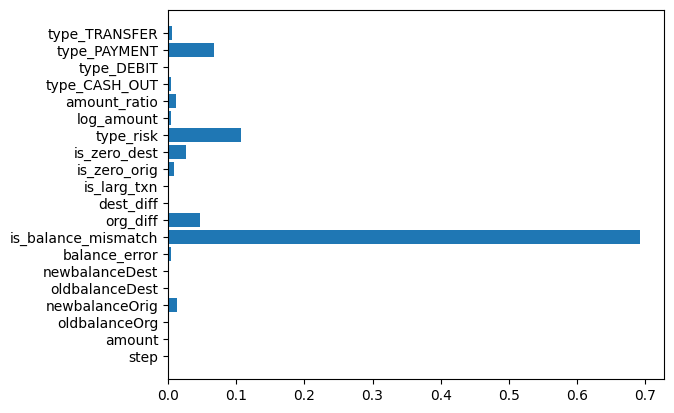

In [ ]:
plt.barh(x.columns, model_XGB.feature_importances_)
plt.show()

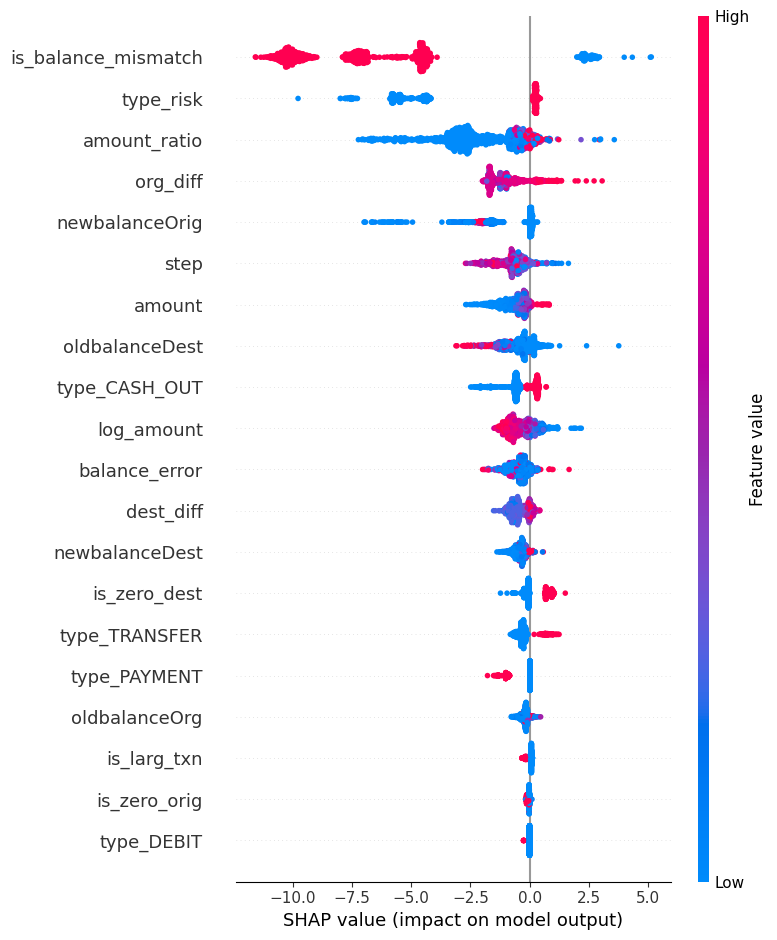

In [71]:
explainer = shap.Explainer(model_XGB)
shap_values = explainer(X_test[:1000])  # sample le warna crash hoga

shap.summary_plot(shap_values, X_test[:1000])

UsageError: Line magic function `%streamlit` not found.
